## Trying to sort class scores into broad functional groups to asses any differences arrival time distributions

1. Build way to group classes into functional groups to simplify
2. Loop over many bins to build list of runtimes for each group
3. analyze yay!


## A group of classes made with chat and some spot checking by MWS
I suspect that many of these will be empty but i think worth keeping some complexity that can be further simplified later
#### Diatoms
Asterionellopsis*
Bacillariophyceae_morphotype1
Cerataulina*
Chaetoceros*
Corethron*
Coscinodiscus*
Cylindrotheca*
Dactyliosolen*
Delphineis*
Ditylum*
Eucampia*
Fragilariopsis*
Guinardia*
Hemiaulus*
Lauderia*
Leptocylindrus*
Licmophora*
Navicula*
Odontella*
Paralia*
Pleurosigma*
Pseudo-nitzschia*
Rhizosolenia*
Skeletonema*
Stephanopyxis*
Thalassionema*
Thalassiosira*
pennate

### Dinoflagellates
Akashiwo*
Alexandrium*
Amphidinium*
Amylax*
Dinophysis*
Gonyaulax*
Gymnodinium*
Gyrodinium*
Heterocapsa*
Karenia*
Katodinium_or_Torodinium
Kryptoperidinium*
Lingulodinium*
Margalefidinium*
Oxytoxum*
Polykrikos*
Prorocentrum*
Protoperidinium*
Scrippsiella*
Tiarina_fusus
Tripos*
Vicicitus_globosus
Warnowia*

### Cryptophytes
Cryptophyta
Leegaardiella_ovalis

### Other Flagellated Phytoplankton (second group is haptophytes condensed down for simplicity)
Apedinella
Dictyocha
Dinobryon
Euglena
Phaeocystis*
Pseudochattonella_farcimen
Pyramimonas*
Trichodesmium
flagellate
flagellate_morphotype1
flagellate_morphotype3

Calciopappus*
Chrysochromulina*
Emiliania_huxleyi
Syracosphaera_pulchra
coccolithophorid

### Cilates
Balanion
Ciliophora
Euplotes*
Eutintinnus
Favella
Laboea_strobila
Mesodinium
Paratontonia_gracillima
Pelagostrobilidium*
Pleuronema
Proterythropsis
Stenosemella*
Strombidium*
Tintinnina
Tintinnopsis
Tontonia_appendiculariformis

### Radiolarians
Acantharia
Acanthoica_quattrospina

### Other Protists
Amoeba
Corymbellus
Ophiaster
Parvicorbicula_socialis

### Metazoans
Copepod_nauplii
Ephemera

### Other 
bad
bead
camera_spot
colony
detritus
detritus_transparent
fecal_pellet
fiber
unknown2


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



## I had chat build a pipeline using a parquet format should be faster the whole pipeline is stored in /utils/class_taxSort

In [2]:
import pyarrow as pa
print(pd.__version__)
print(pa.__version__)

2.3.0
24.0.0


In [ ]:
## checking if it looks like it worked 
## if this does not load try resarting your kernel and running the cells again

test_df = pd.read_parquet("/Users/michaelstaiger/Desktop/ifcb_pipeline_starter/data/processed/master_particles.parquet")

In [4]:
test_df.head()

,source_file,sample_datetime,trigger#,RoiNumber,PMTB,ADCtime,RunTime,InhibitTime,InhibitTimeDiff,VolumeAnalyzed,RoiType,RoiHeight,RoiWidth,RoiX,RoiY,pid,best_class,best_score,collapsed_class,taxonomic_group
0,D20230727T030526_IFCB145_merged_keepzero.csv,2023-07-27T03:05:26,2,2,-0.001822,21.039895,21.060955,0.081471,0.081471,0.087415,1,52,64,972,198,D20230727T030526_IFCB145_00002,detritus,0.6235,detritus,artifact_or_detritus
1,D20230727T030526_IFCB145_merged_keepzero.csv,2023-07-27T03:05:26,3,3,-0.001395,21.168397,21.189681,0.163457,0.081986,0.087609,0,0,0,0,0,None,Acantharia,0.0000,Acantharia,radiolarian_or_acantharian
2,D20230727T030526_IFCB145_merged_keepzero.csv,2023-07-27T03:05:26,4,4,0.001301,21.366885,21.388140,0.245671,0.082214,0.088094,1,116,136,916,518,D20230727T030526_IFCB145_00004,Amphidinium,0.9756,Amphidinium,dinoflagellate
3,D20230727T030526_IFCB145_merged_keepzero.csv,2023-07-27T03:05:26,5,5,-0.001696,22.148208,22.171018,0.328911,0.083240,0.091009,1,44,80,972,406,D20230727T030526_IFCB145_00005,detritus,0.5723,detritus,artifact_or_detritus
4,D20230727T030526_IFCB145_merged_keepzero.csv,2023-07-27T03:05:26,6,6,-0.001585,22.614758,22.636172,0.411380,0.082470,0.092603,1,68,88,956,0,D20230727T030526_IFCB145_00006,detritus,0.9976,detritus,artifact_or_detritus


In [7]:
diatom_df = test_df[test_df["taxonomic_group"] == "diatom"]

In [8]:
diatom_df.head()

,source_file,sample_datetime,trigger#,RoiNumber,PMTB,ADCtime,RunTime,InhibitTime,InhibitTimeDiff,VolumeAnalyzed,RoiType,RoiHeight,RoiWidth,RoiX,RoiY,pid,best_class,best_score,collapsed_class,taxonomic_group
11,D20230727T030526_IFCB145_merged_keepzero.csv,2023-07-27T03:05:26,13,13,-0.001289,24.541930,24.563865,0.993513,0.083492,0.098210,1,76,200,868,350,D20230727T030526_IFCB145_00013,Leptocylindrus,0.4092,Leptocylindrus,diatom
19,D20230727T030526_IFCB145_merged_keepzero.csv,2023-07-27T03:05:26,21,21,-0.001895,28.052826,28.075061,1.657791,0.083127,0.110072,1,52,80,964,398,D20230727T030526_IFCB145_00021,Cylindrotheca_morphotype1,0.3660,Cylindrotheca*,diatom
20,D20230727T030526_IFCB145_merged_keepzero.csv,2023-07-27T03:05:26,22,22,-0.001717,28.156934,28.178767,1.740404,0.082613,0.110160,1,92,96,956,574,D20230727T030526_IFCB145_00022,Skeletonema,0.8310,Skeletonema,diatom
32,D20230727T030526_IFCB145_merged_keepzero.csv,2023-07-27T03:05:26,34,34,0.001936,32.120000,32.141235,2.733993,0.081654,0.122530,1,108,128,956,94,D20230727T030526_IFCB145_00034,Eucampia,0.8745,Eucampia,diatom
38,D20230727T030526_IFCB145_merged_keepzero.csv,2023-07-27T03:05:26,40,40,-0.001609,34.001203,34.023974,3.232142,0.083650,0.128299,1,44,64,980,134,D20230727T030526_IFCB145_00040,Cylindrotheca_morphotype1,0.6694,Cylindrotheca*,diatom


/var/folders/l8/3r0hwyy91wg_66xlwdssv2yr0000gn/T/ipykernel_78914/2652816411.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


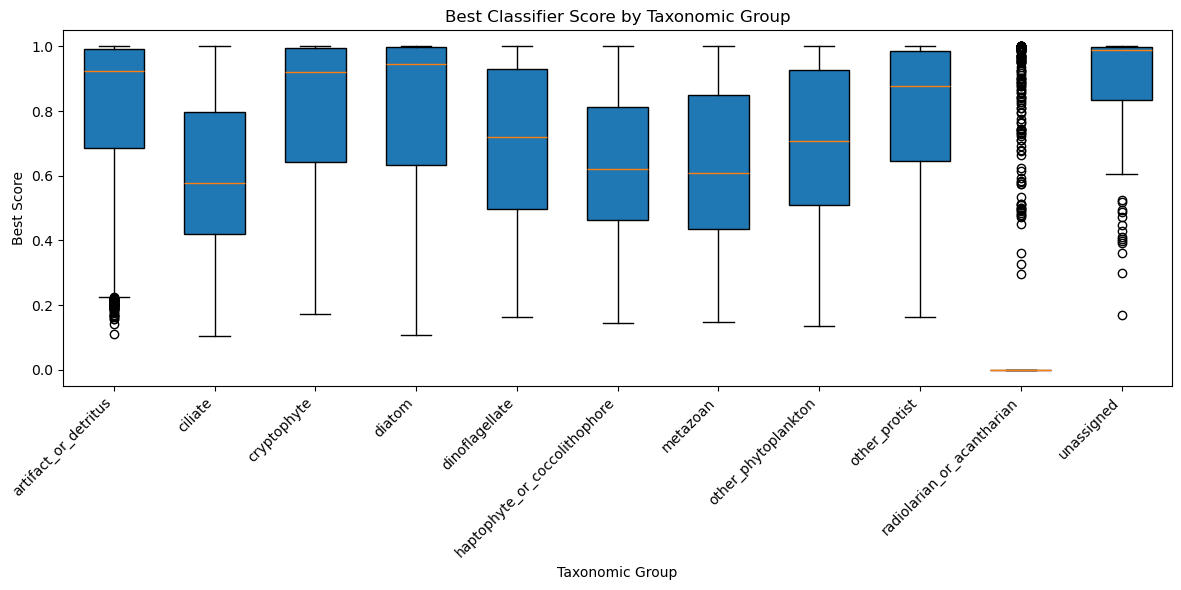

In [14]:
import matplotlib.pyplot as plt
import numpy as np

groups = sorted(test_df["taxonomic_group"].dropna().unique())

data = [
    test_df.loc[test_df["taxonomic_group"] == group, "best_score"].dropna()
    for group in groups
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    data,
    labels=groups,
    widths=0.6,
    patch_artist=True
)

plt.xlabel("Taxonomic Group")
plt.ylabel("Best Score")
plt.title("Best Classifier Score by Taxonomic Group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/var/folders/l8/3r0hwyy91wg_66xlwdssv2yr0000gn/T/ipykernel_78914/4280740449.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


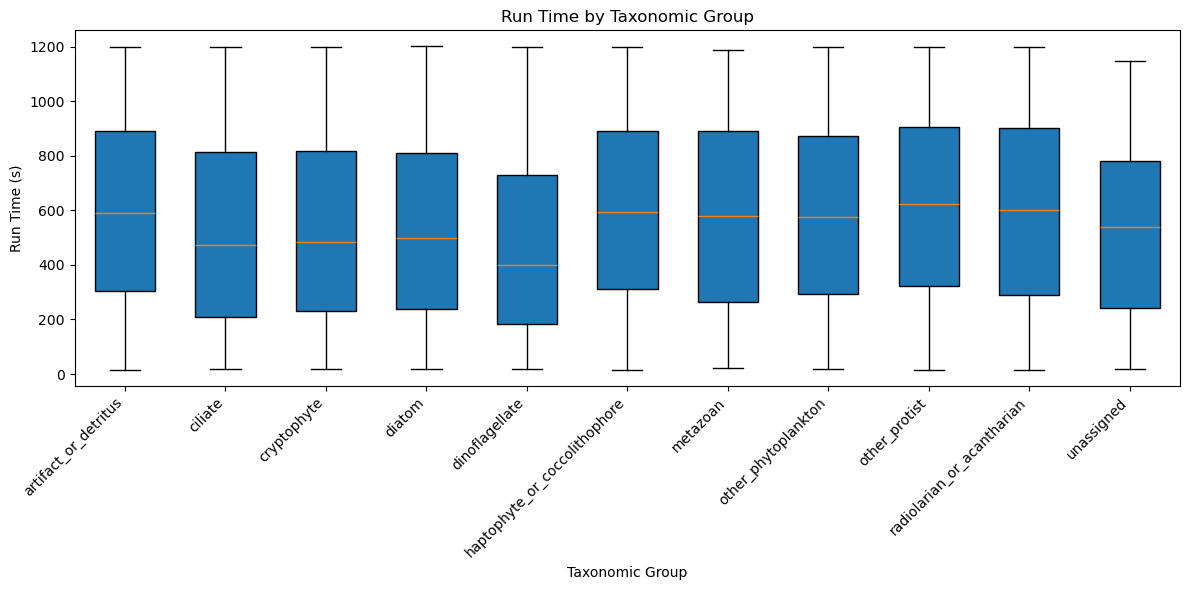

In [16]:
import matplotlib.pyplot as plt
import numpy as np

groups = sorted(test_df["taxonomic_group"].dropna().unique())

data = [
    test_df.loc[test_df["taxonomic_group"] == group, "RunTime"].dropna()
    for group in groups
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    data,
    labels=groups,
    widths=0.6,
    patch_artist=True
)

plt.xlabel("Taxonomic Group")
plt.ylabel("Run Time (s)")
plt.title("Run Time by Taxonomic Group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
filtered_df = test_df[test_df["best_score"] > 0.9]

filtered_df["taxonomic_group"].value_counts()

taxonomic_group
artifact_or_detritus             17312
diatom                            7511
other_phytoplankton               3566
other_protist                     1976
dinoflagellate                    1042
cryptophyte                        861
haptophyte_or_coccolithophore      468
ciliate                            262
unassigned                          77
radiolarian_or_acantharian          66
metazoan                            43
Name: count, dtype: int64

/var/folders/l8/3r0hwyy91wg_66xlwdssv2yr0000gn/T/ipykernel_78914/1745737620.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


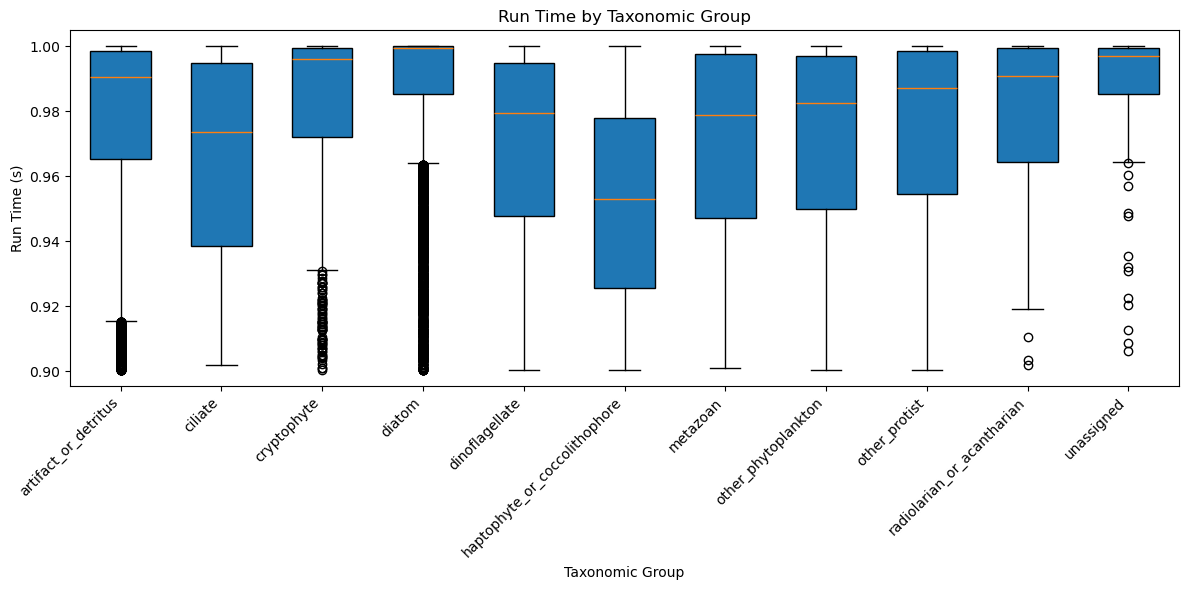

In [21]:
import matplotlib.pyplot as plt
import numpy as np

groups = sorted(filtered_df["taxonomic_group"].dropna().unique())

data = [
    filtered_df.loc[filtered_df["taxonomic_group"] == group, "best_score"].dropna()
    for group in groups
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    data,
    labels=groups,
    widths=0.6,
    patch_artist=True
)

plt.xlabel("Taxonomic Group")
plt.ylabel("Run Time (s)")
plt.title("Run Time by Taxonomic Group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()